### Initial Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### EDA

In [2]:
df = pd.read_csv('telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 7043
Number of columns: 21


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# descriptive statistics
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
# dataferame showing data type, number of nulls, negatives, zeros, and unique values in each column
numeric_cols = df.select_dtypes(include=np.number).columns

summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Nulls': df.isnull().sum(),
    'Negatives': (df[numeric_cols] < 0).sum().reindex(df.columns),
    'Zeros': (df[numeric_cols] == 0).sum().reindex(df.columns),
    'Unique Values': df.nunique()
})
summary_df

,Data Type,Nulls,Negatives,Zeros,Unique Values
customerID,str,0,NaN,NaN,7043
gender,str,0,NaN,NaN,2
SeniorCitizen,int64,0,0.0,5901.0,2
Partner,str,0,NaN,NaN,2
Dependents,str,0,NaN,NaN,2
tenure,int64,0,0.0,11.0,73
PhoneService,str,0,NaN,NaN,2
MultipleLines,str,0,NaN,NaN,3
InternetService,str,0,NaN,NaN,3
OnlineSecurity,str,0,NaN,NaN,3


In [7]:
# display the unique values in each column excluding cusomterID and columns with more than 10 unique values
for col in df.columns:
    if col != 'customerID' and df[col].nunique() <= 10:
        print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique values in 'SeniorCitizen': [0 1]
Unique values in 'Partner': <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique values in 'Dependents': <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in 'PhoneService': <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in 'MultipleLines': <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Unique values in 'InternetService': <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Unique values in 'OnlineSecurity': <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Unique values in 'OnlineBackup': <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Unique values in 'DeviceProtection': <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Unique values in 'TechSupport': <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Un

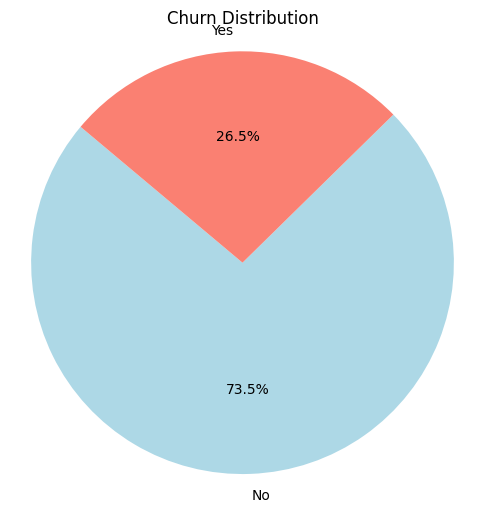

In [8]:
# churn distribution pie chart
plt.figure(figsize=(6, 6))
labels = df['Churn'].value_counts().index
sizes = df['Churn'].value_counts().values
colors = ['lightblue', 'salmon']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Churn Distribution')
plt.axis('equal')
plt.show()

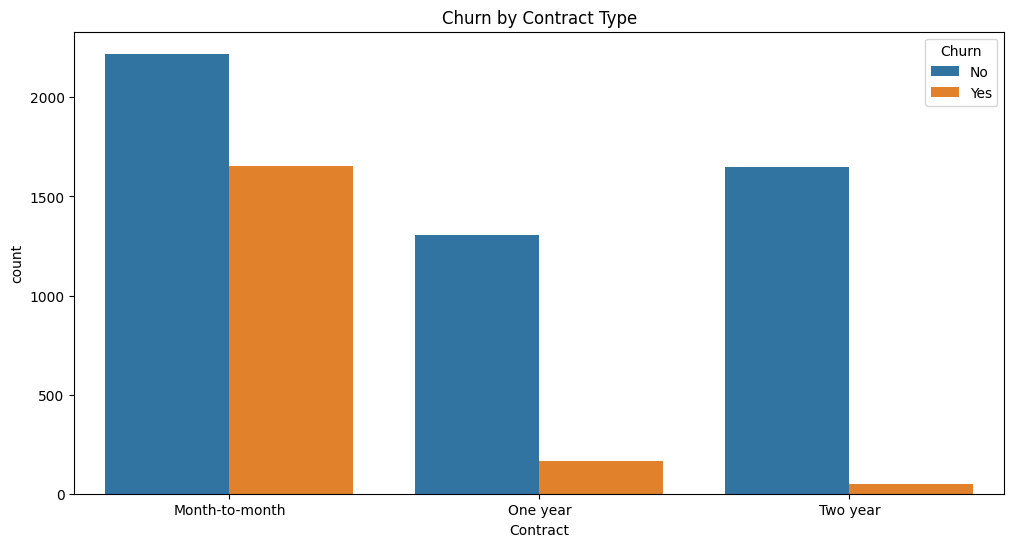

In [9]:
# multivariate analysis
plt.figure(figsize=(12, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

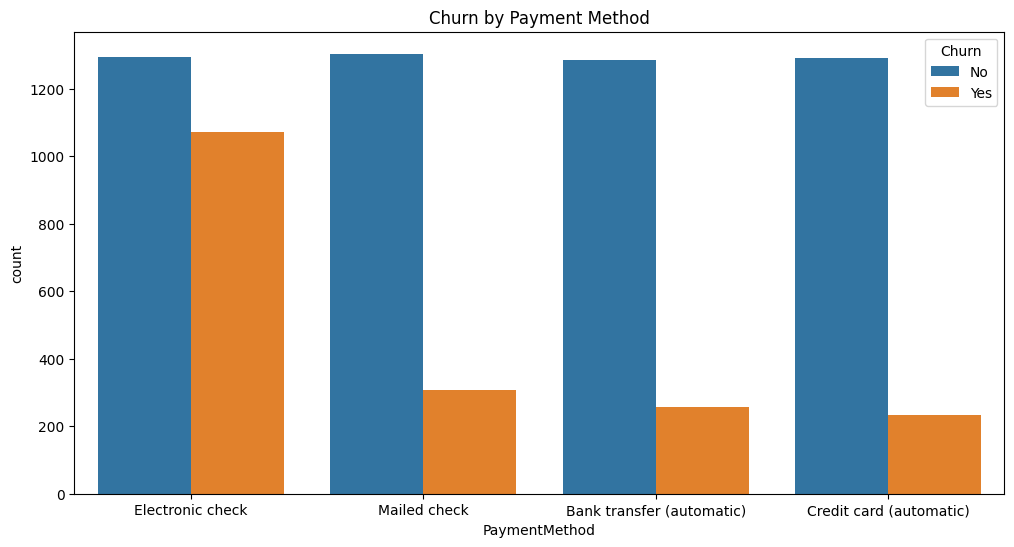

In [10]:
# churn by payment method
plt.figure(figsize=(12, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn by Payment Method')
plt.show()

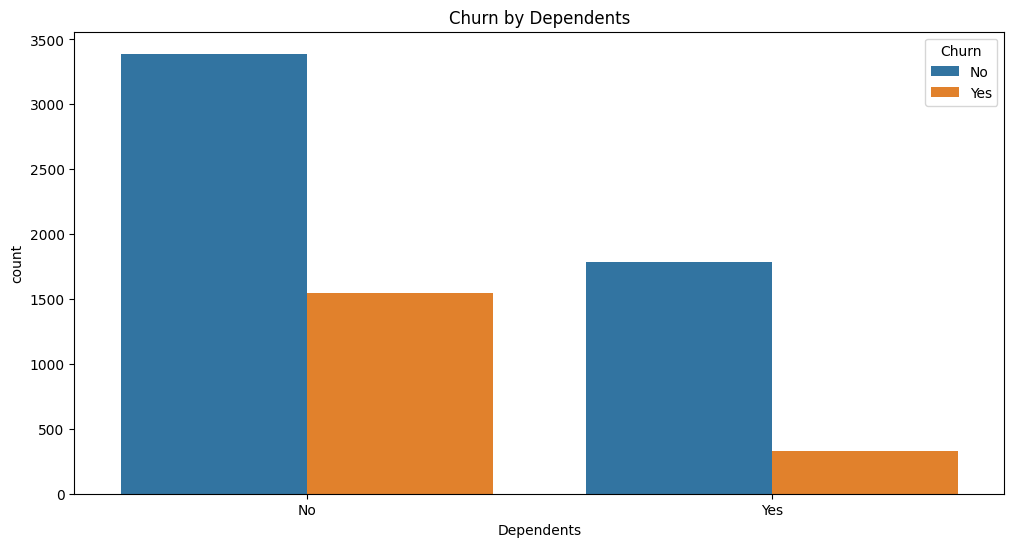

In [11]:
# churn by dependent variable
plt.figure(figsize=(12, 6))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title('Churn by Dependents')
plt.show()

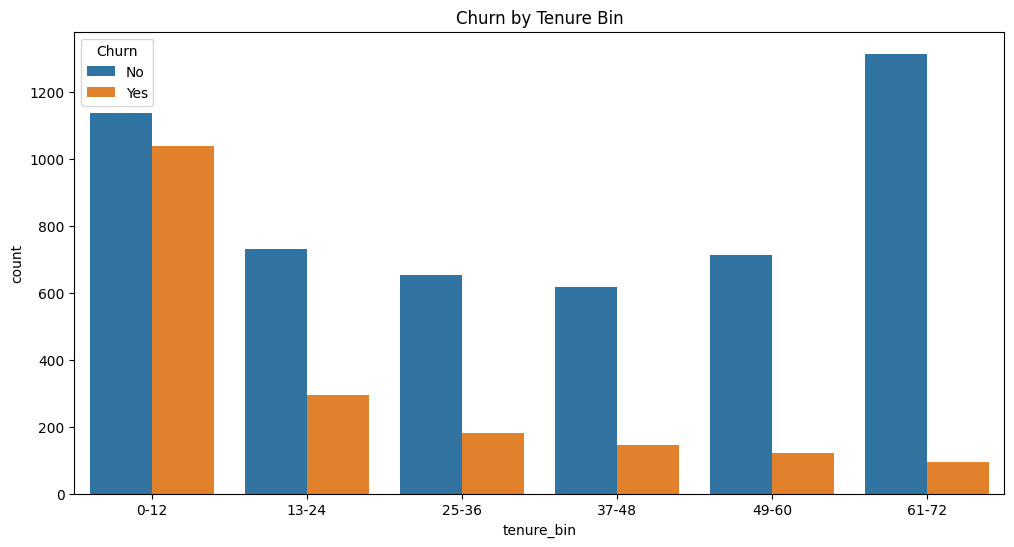

In [12]:
# bar chart to show churn by tenure bin tenure
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72], labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])
plt.figure(figsize=(12, 6))
sns.countplot(x='tenure_bin', hue='Churn', data=df)
plt.title('Churn by Tenure Bin')
plt.show()

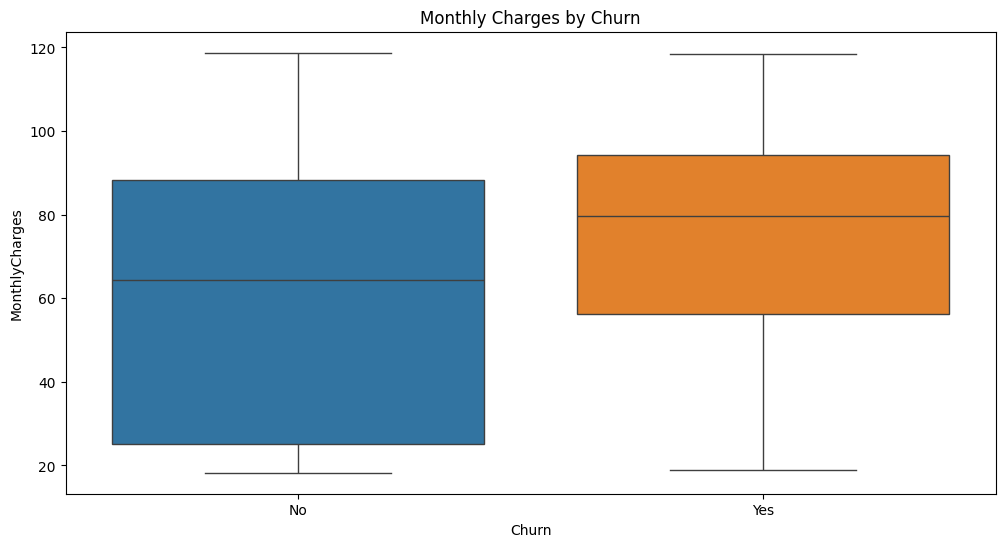

In [13]:
# box plot of monthly charges by churn
plt.figure(figsize=(12, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn')
plt.title('Monthly Charges by Churn')
plt.show()

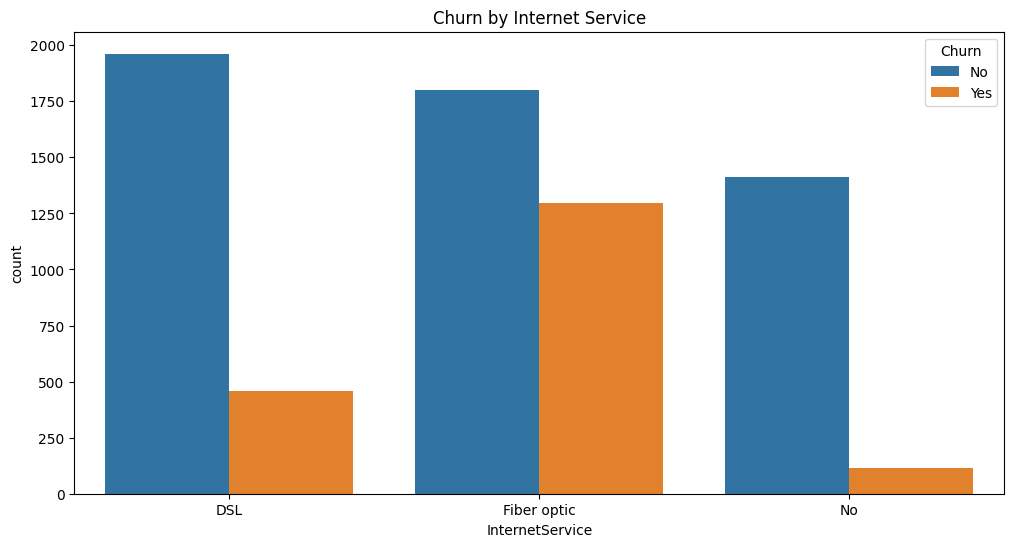

In [14]:
# churn by internet service
plt.figure(figsize=(12, 6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.show()

### Preprocessing

In [15]:
# drop unnecessary columns
df.drop(columns=['customerID', 'PhoneService', 'TotalCharges', 'tenure_bin'], inplace=True)
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'Churn'],
      dtype='str')

In [16]:
# encode categorical variables using one-hot encoding, encode Churn using label encoding
df = pd.get_dummies(df, drop_first=True)
df['Churn'] = df['Churn_Yes']
df.drop(columns=['Churn_Yes'], inplace=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,False,True,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


In [17]:
# convert True and False to 1 and 0 in all columns
df = df.replace({True: 1, False: 0})
df.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   gender_Male                            7043 non-null   object 
 4   Partner_Yes                            7043 non-null   object 
 5   Dependents_Yes                         7043 non-null   object 
 6   MultipleLines_No phone service         7043 non-null   object 
 7   MultipleLines_Yes                      7043 non-null   object 
 8   InternetService_Fiber optic            7043 non-null   object 
 9   InternetService_No                     7043 non-null   object 
 10  OnlineSecurity_No internet service     7043 non-null   object 
 11  OnlineSecurity_

In [19]:
# change object columns to numeric
for col in df.select_dtypes(include='object').columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   gender_Male                            7043 non-null   int64  
 4   Partner_Yes                            7043 non-null   int64  
 5   Dependents_Yes                         7043 non-null   int64  
 6   MultipleLines_No phone service         7043 non-null   int64  
 7   MultipleLines_Yes                      7043 non-null   int64  
 8   InternetService_Fiber optic            7043 non-null   int64  
 9   InternetService_No                     7043 non-null   int64  
 10  OnlineSecurity_No internet service     7043 non-null   int64  
 11  OnlineSecurity_

In [20]:
# correlation
corr = df.corr()
corr_target = corr['Churn'].abs().sort_values(ascending=False)

# select top features
selected_features = corr_target.drop('Churn').head(10).index

selected_features

Index(['tenure', 'InternetService_Fiber optic', 'Contract_Two year',
       'PaymentMethod_Electronic check', 'OnlineSecurity_No internet service',
       'StreamingMovies_No internet service',
       'StreamingTV_No internet service', 'TechSupport_No internet service',
       'OnlineBackup_No internet service',
       'DeviceProtection_No internet service'],
      dtype='str')

### Modeling

In [21]:
# define features and target
X = df[selected_features]
y = df['Churn']

In [22]:
# imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# preprocessing
from sklearn.preprocessing import StandardScaler

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# cross validation
from sklearn.model_selection import cross_val_score

# pipelines
logreg_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=100))
])

xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(max_depth=10, min_child_weight=5, n_estimators=100))
])

# cross validation num of folds
cv = 5

print("LogReg:", cross_val_score(logreg_pipeline, X, y, cv=cv, scoring='accuracy').mean())
print("RF:", cross_val_score(rf_pipeline, X, y, cv=cv, scoring='accuracy').mean())
print("XGB:", cross_val_score(xgb_pipeline, X, y, cv=cv, scoring='accuracy').mean())

LogReg: 0.7298024267694689
RF: 0.7303690963933157
XGB: 0.7229862612104008


### Evaluation

In [23]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
cv = 5

# Logistic Regression
logreg_results = cross_validate(logreg_pipeline, X, y, cv=cv, scoring=scoring)

# Random Forest
rf_results = cross_validate(rf_pipeline, X, y, cv=cv, scoring=scoring)

# XGBoost
xgb_results = cross_validate(xgb_pipeline, X, y, cv=cv, scoring=scoring)

# print results
print(f"""
Logistic Regression:
  Accuracy : {logreg_results['test_accuracy'].mean():.4f}
  Precision: {logreg_results['test_precision_weighted'].mean():.4f}
  Recall   : {logreg_results['test_recall_weighted'].mean():.4f}
  F1 Score : {logreg_results['test_f1_weighted'].mean():.4f}


Random Forest:
  Accuracy : {rf_results['test_accuracy'].mean():.4f}
  Precision: {rf_results['test_precision_weighted'].mean():.4f}
  Recall   : {rf_results['test_recall_weighted'].mean():.4f}
  F1 Score : {rf_results['test_f1_weighted'].mean():.4f}


XGBoost:
  Accuracy : {xgb_results['test_accuracy'].mean():.4f}
  Precision: {xgb_results['test_precision_weighted'].mean():.4f}
  Recall   : {xgb_results['test_recall_weighted'].mean():.4f}
  F1 Score : {xgb_results['test_f1_weighted'].mean():.4f}
""")


Logistic Regression:
  Accuracy : 0.7298
  Precision: 0.7965
  Recall   : 0.7298
  F1 Score : 0.7446


Random Forest:
  Accuracy : 0.7289
  Precision: 0.7923
  Recall   : 0.7289
  F1 Score : 0.7435


XGBoost:
  Accuracy : 0.7230
  Precision: 0.7862
  Recall   : 0.7230
  F1 Score : 0.7379



In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# predictions using cross validation
y_pred_logreg = cross_val_predict(logreg_pipeline, X, y, cv=cv)
y_pred_rf = cross_val_predict(rf_pipeline, X, y, cv=cv)
y_pred_xgb = cross_val_predict(xgb_pipeline, X, y, cv=cv)

# confusion matrix
conf_matrix_logreg = confusion_matrix(y, y_pred_logreg)
conf_matrix_rf = confusion_matrix(y, y_pred_rf)
conf_matrix_xgb = confusion_matrix(y, y_pred_xgb)

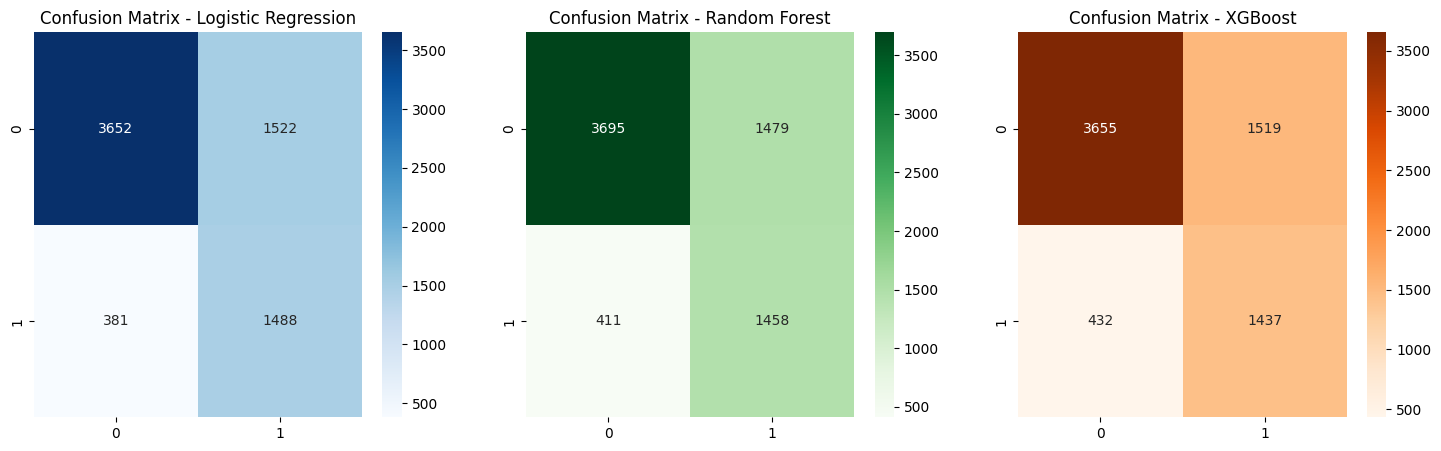

In [25]:
# plot confusion matrix for each model
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')

plt.subplot(1, 3, 2)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')

plt.subplot(1, 3, 3)
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')

plt.show()

In [26]:
# fit models on full dataset after cv
logreg_pipeline.fit(X, y)
rf_pipeline.fit(X, y)
xgb_pipeline.fit(X, y)

logreg_model, rf_model, xgb_model_final = (
    logreg_pipeline['model'],
    rf_pipeline['model'],
    xgb_pipeline['model']
)

# feature importance
feature_importance_rf = rf_model.feature_importances_
feature_importance_xgb = xgb_model_final.feature_importances_
feature_importance_logreg = np.abs(logreg_model.coef_[0])

feature_names = X.columns

# dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest Importance': feature_importance_rf,
    'XGBoost Importance': feature_importance_xgb,
    'Logistic Regression Importance': feature_importance_logreg
})

feature_importance_df.set_index('Feature', inplace=True)

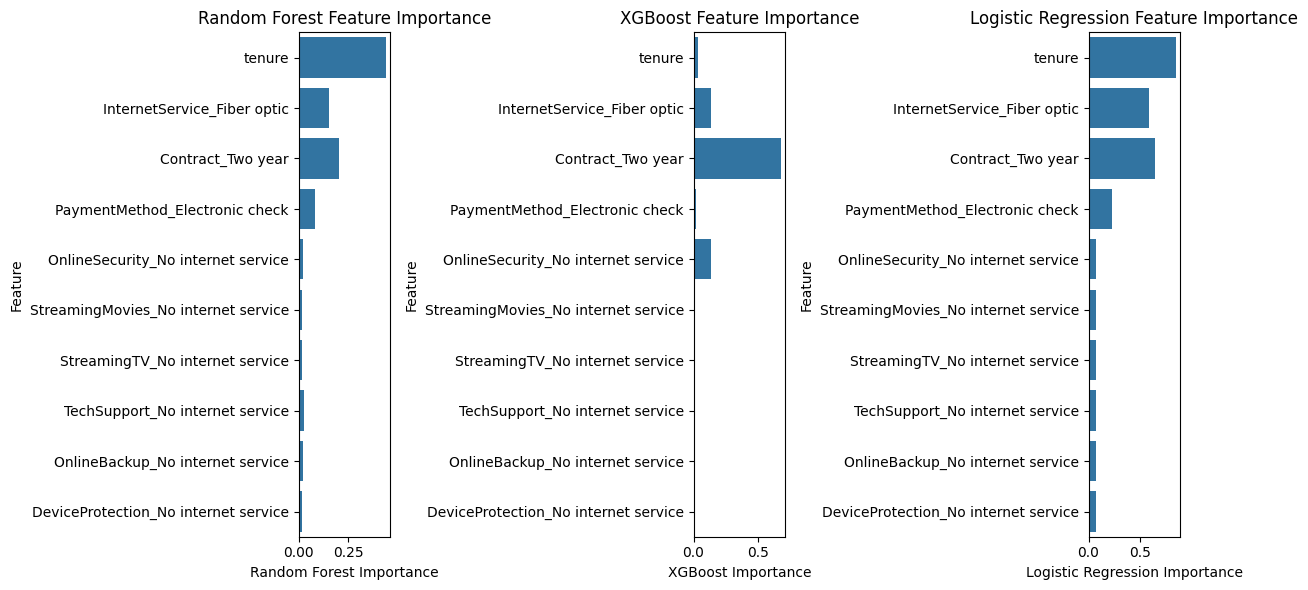

In [27]:
# show the top 10 important features for each model in a bar chart
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.barplot(x=feature_importance_df['Random Forest Importance'].head(10), y=feature_importance_df.index[:10])
plt.title('Random Forest Feature Importance')

plt.subplot(1, 3, 2)
sns.barplot(x=feature_importance_df['XGBoost Importance'].head(10), y=feature_importance_df.index[:10])
plt.title('XGBoost Feature Importance')

plt.subplot(1, 3, 3)
sns.barplot(x=feature_importance_df['Logistic Regression Importance'].head(10), y=feature_importance_df.index[:10])
plt.title('Logistic Regression Feature Importance')

plt.tight_layout()
plt.show()

### ROC AUC

In [ ]:
# roc and auc curves for each model
from sklearn.metrics import roc_curve, auc
y_prob_logreg = cross_val_predict(logreg_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]
y_prob_rf = cross_val_predict(rf_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]
y_prob_xgb = cross_val_predict(xgb_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

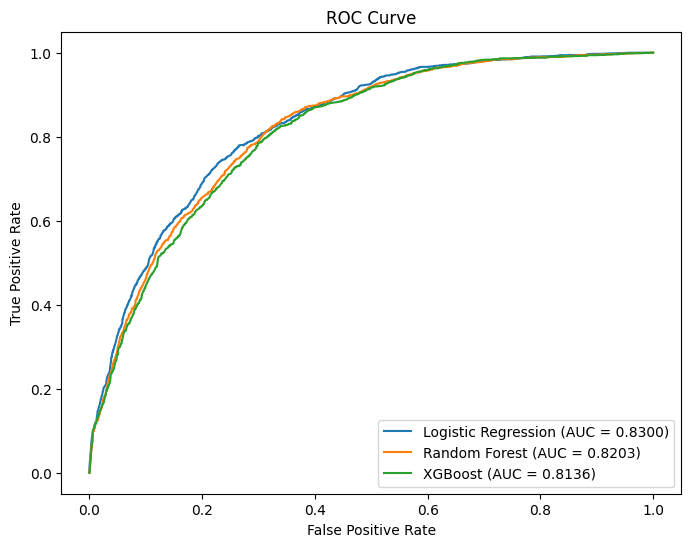

In [30]:
# plot roc curve for each model
fpr_logreg, tpr_logreg, _ = roc_curve(y, y_prob_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y, y_prob_xgb)
# display roc curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc(fpr_logreg, tpr_logreg):.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.4f})')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()